### This notebook loads the summary of Heart Rate from subjects of Social dataset and looks into systematic differences across tasks

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf

In [28]:
# group_by_var = 'task_name'
group_by_var = 'task_cond'

# load HR summary tsv
tsv_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/physio/HR_summary.tsv'
hr_df = pd.read_csv(tsv_path, sep='\t')
hr_df.head()

,subj_id,run_num,task_name,task_code,task_cond,avg_instruction_HR,avg_task_HR
0,sub-05,1,action_prediction,action_prediction,action_prediction_greeting_hard,57.104500,56.659217
1,sub-05,1,frith_happe,frith_happe,frith_happe_tom,57.615986,57.468941
2,sub-05,1,theory_of_mind,tom,theory_of_mind_belief,59.004135,58.739100
3,sub-05,1,strange_stories,strange_stories,strange_stories_social,59.347420,58.251872
4,sub-05,1,liking,liking,liking_like,58.661684,59.130879


In [29]:
# Make sure group_by_var is categorical
hr_df[group_by_var] = hr_df[group_by_var].astype('category')

# Reorder categories so 'rest' is first (the reference)
categories = ['rest'] + [t for t in hr_df[group_by_var].cat.categories if t != 'rest']
hr_df[group_by_var] = hr_df[group_by_var].cat.reorder_categories(categories, ordered=True)

# Average across all subjects & runs
task_means = hr_df.groupby(group_by_var)[["avg_instruction_HR", "avg_task_HR"]].mean()
print(task_means)

                                 avg_instruction_HR  avg_task_HR
task_cond                                                       
rest                                      65.150072    63.642846
action_prediction_greeting_hard           65.297235    64.586073
action_prediction_soccer_hard             66.108981    65.229472
demand_grid                               65.395849    65.911900
faux_pas_control                          65.471500    65.178954
faux_pas_social                           65.513528    65.122506
frith_happe_random                        65.898400    64.341467
frith_happe_tom                           65.322472    63.360797
liking_control                            65.861918    64.719553
liking_like                               65.573935    64.897375
picture_sequence_control                  65.640026    64.427952
picture_sequence_fbelief                  65.863682    64.627481
rmet_age                                  65.495889    64.671745
rmet_emotion             

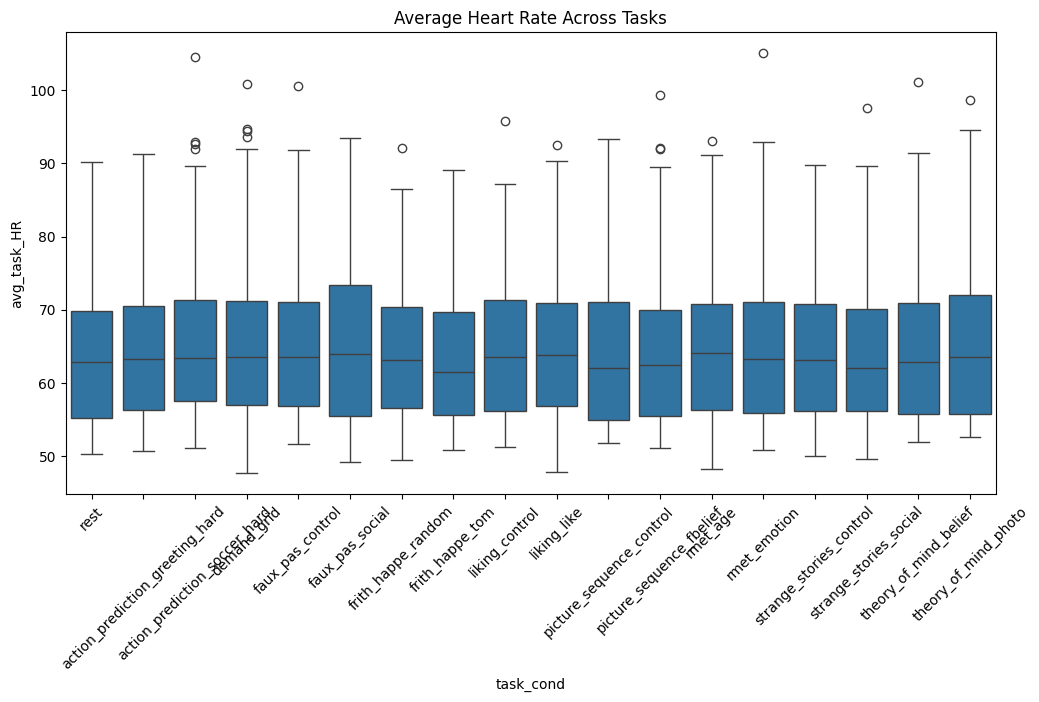

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=group_by_var, y="avg_task_HR", data=hr_df)
plt.title("Average Heart Rate Across Tasks")
plt.xticks(rotation=45)
plt.show()

In [31]:
# Group data into lists, one per task
task_groups = [group["avg_task_HR"].values for _, group in hr_df.groupby(group_by_var)]

# One-way ANOVA
f_val, p_val = stats.f_oneway(*task_groups)
print(f"ANOVA: F={f_val:.3f}, p={p_val:.3e}")

ANOVA: F=0.482, p=9.619e-01


In [32]:
# Average HR across runs per subject per task
subject_task_avg = hr_df.groupby(['subj_id',group_by_var])['avg_task_HR'].mean().reset_index()

# Prepare for one-way ANOVA: one array per task
task_groups = [g['avg_task_HR'].values for _, g in subject_task_avg.groupby(group_by_var)]

# One-way ANOVA
f_val, p_val = stats.f_oneway(*task_groups)
print(f"ANOVA on per-subject averages: F={f_val:.3f}, p={p_val:.3f}")

ANOVA on per-subject averages: F=0.064, p=1.000
